Saving Resume.csv to Resume.csv
Dataset Shape: (2484, 4)

Required Skills
['data analysis', 'pandas', 'numpy', 'python', 'machine learning', 'sql', 'git']

TOP 10 CANDIDATES
            ID                Category  Match Score  \
1717  50328713             ENGINEERING        71.43   
1762  12011623             ENGINEERING        71.43   
1339  18448085              AUTOMOBILE        71.43   
1348  22946204              AUTOMOBILE        57.14   
1218  21156767              CONSULTANT        57.14   
1152  39441617              CONSULTANT        42.86   
1695  82246962             ENGINEERING        42.86   
1172  95429627              CONSULTANT        42.86   
331   18067556  INFORMATION-TECHNOLOGY        42.86   
1113  88907739              CONSULTANT        42.86   

                                         Matched Skills  \
1717         pandas, python, machine learning, sql, git   
1762  data analysis, pandas, python, machine learnin...   
1339          data analysis, pandas, numpy,

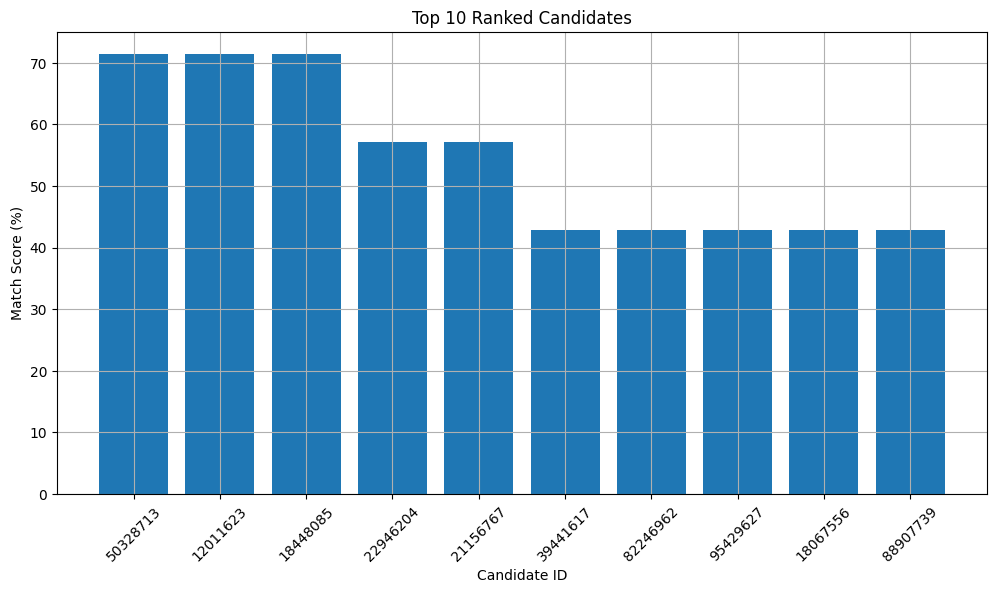

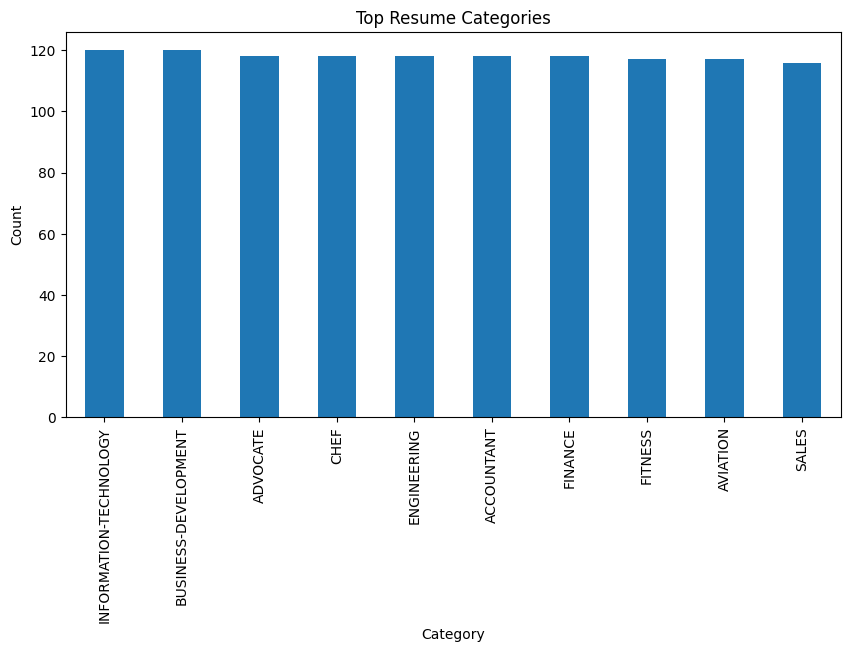


Saved as candidate_ranking.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


BUSINESS INSIGHTS
Candidates are ranked based on skill match with the job description.
Missing skills help recruiters identify training needs.
Top-ranked candidates should be shortlisted first.


In [1]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt

from google.colab import files

# ==========================================
# UPLOAD DATASET
# ==========================================

uploaded = files.upload()

filename = list(uploaded.keys())[0]

df = pd.read_csv(filename)

print("Dataset Shape:", df.shape)

# ==========================================
# USE RESUME TEXT COLUMN
# ==========================================

df = df[['ID','Resume_str','Category']]

df.dropna(inplace=True)

# ==========================================
# JOB DESCRIPTION
# ==========================================

job_description = """
Python Developer

Required Skills:
Python
Machine Learning
SQL
Pandas
NumPy
Scikit-Learn
Git
Data Analysis
"""

# ==========================================
# SKILL DATABASE
# ==========================================

skills_db = [

    "python",
    "machine learning",
    "sql",
    "pandas",
    "numpy",
    "scikit-learn",
    "git",
    "data analysis",
    "tensorflow",
    "keras",
    "deep learning",
    "nlp",
    "tableau",
    "power bi",
    "excel",
    "java",
    "c++"
]

# ==========================================
# CLEAN TEXT
# ==========================================

def clean_text(text):

    text = str(text).lower()

    text = re.sub(
        r'[^a-zA-Z0-9+# ]',
        ' ',
        text
    )

    return text

# ==========================================
# EXTRACT SKILLS
# ==========================================

def extract_skills(text):

    text = clean_text(text)

    skills_found = []

    for skill in skills_db:

        if skill in text:

            skills_found.append(skill)

    return list(set(skills_found))

# ==========================================
# JOB SKILLS
# ==========================================

jd_skills = extract_skills(
    job_description
)

print("\nRequired Skills")

print(jd_skills)

# ==========================================
# SCORE RESUMES
# ==========================================

results = []

for _, row in df.iterrows():

    resume_text = row["Resume_str"]

    candidate_skills = extract_skills(
        resume_text
    )

    matched = list(
        set(candidate_skills)
        &
        set(jd_skills)
    )

    missing = list(
        set(jd_skills)
        -
        set(candidate_skills)
    )

    score = (
        len(matched)
        /
        len(jd_skills)
    ) * 100

    results.append({

        "ID":
        row["ID"],

        "Category":
        row["Category"],

        "Match Score":
        round(score,2),

        "Matched Skills":
        ", ".join(matched),

        "Missing Skills":
        ", ".join(missing)
    })

# ==========================================
# CREATE RESULTS TABLE
# ==========================================

results_df = pd.DataFrame(
    results
)

results_df = results_df.sort_values(
    by="Match Score",
    ascending=False
)

# ==========================================
# TOP 10 CANDIDATES
# ==========================================

print("\nTOP 10 CANDIDATES")

print(
    results_df.head(10)
)

# ==========================================
# BEST CANDIDATE
# ==========================================

best = results_df.iloc[0]

print("\nBEST MATCH")

print("Candidate ID:", best["ID"])

print("Category:", best["Category"])

print("Score:", best["Match Score"])

# ==========================================
# VISUALIZATION
# ==========================================

top10 = results_df.head(10)

plt.figure(
    figsize=(12,6)
)

plt.bar(
    top10["ID"].astype(str),
    top10["Match Score"]
)

plt.title(
    "Top 10 Ranked Candidates"
)

plt.xlabel("Candidate ID")

plt.ylabel("Match Score (%)")

plt.xticks(rotation=45)

plt.grid(True)

plt.show()

# ==========================================
# CATEGORY ANALYSIS
# ==========================================

plt.figure(
    figsize=(10,5)
)

df["Category"].value_counts().head(10).plot(
    kind="bar"
)

plt.title(
    "Top Resume Categories"
)

plt.ylabel("Count")

plt.show()

# ==========================================
# SAVE RESULTS
# ==========================================

results_df.to_csv(
    "candidate_ranking.csv",
    index=False
)

print(
    "\nSaved as candidate_ranking.csv"
)

files.download(
    "candidate_ranking.csv"
)

# ==========================================
# BUSINESS INSIGHTS
# ==========================================

print("\nBUSINESS INSIGHTS")

print(
    "Candidates are ranked based on skill match with the job description."
)

print(
    "Missing skills help recruiters identify training needs."
)

print(
    "Top-ranked candidates should be shortlisted first."
)